In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['MUJOCO_GL'] = 'egl'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import sys

sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")


In [19]:
from analysis.utils import reconstruct_cartpole_dmcontrol

In [20]:
from envs import make_env
from omegaconf import OmegaConf

## In policy data

In [26]:
from analysis.utils import load_sweep_metadata, load_data

CKPT_TO_USE = 500_000
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))
# df['angle_degrees'] = df['initial_state'].apply(lambda x: np.degrees(x[1]))
# #df = df[~df['angle_degrees'].isin([0.0, 360.0])]

df = df[df['ckpt_int'] == CKPT_TO_USE]
z_inpolicy = np.concatenate(df['latent_states'].tolist())
obs_inpolicy = np.concatenate(df['observations'].tolist())
actions_inpolicy = np.concatenate(df['actions'].tolist())
rewards_inpolicy = np.concatenate(df['rewards'].tolist()).reshape(-1, 1)

frames_inpolicy = reconstruct_cartpole_dmcontrol(obs_inpolicy,
                                                 height=64,
                                                 width=64,
                                                 return_frames=True)
frames_inpolicy = np.array(frames_inpolicy)

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 8412.29it/s]


Found 108 configurations
Found 108 configurations


100%|██████████| 9000/9000 [01:32<00:00, 97.52it/s] 


In [27]:
frames_inpolicy.shape

(9000, 64, 64, 3)

In [28]:
import pickle
import os

data_in_policy = {
    'obs_states': obs_inpolicy,
    'obs_pixels': frames_inpolicy,
    'actions': actions_inpolicy,
    'rewards': rewards_inpolicy,
}

# Directory to save data
save_dir = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation'
os.makedirs(save_dir, exist_ok=True)

# Save data for in-policy, off-policy, and passive episodes
with open(os.path.join(save_dir, 'data_in_policy.pkl'), 'wb') as f:
    pickle.dump(data_in_policy, f)

## Off policy data

In [29]:
from analysis.utils_data_generation import collect_data

In [30]:
cfg_state = OmegaConf.create({
    'task': 'cartpole-swingup',
    'obs': 'state',
    'seed': 0,
    'multitask': False,
})

env_state = make_env(cfg_state)

In [31]:
#Example usage:

initial_positions = [-1.5, -1, 0, 1, 1.5]
initial_angles = np.radians(np.linspace(0, 360, 10))

initial_states = []
for initial_position in initial_positions:
    for initial_angle in initial_angles:
        initial_states.append(
            {
                'qpos': {
                    'slider': initial_position,
                    'hinge_1': initial_angle,
                },
                'qvel': {
                    'slider': 0.0,
                    'hinge_1': 0.0
                }
            },)

episodes_offpolicy = collect_data(env_state,
                                  max_steps=500,
                                  seed=1,
                                  initial_states=initial_states,
                                  n_episodes_per_initial_state=1,
                                  is_rgb=False)
print(len(episodes_offpolicy), len(episodes_offpolicy[0]),
      episodes_offpolicy[0][0]["obs_next"])


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:09<00:00,  5.16it/s]


50 500 tensor([-1.5000e+00,  1.0000e+00, -4.8863e-05,  3.3627e-03, -4.8887e-03])


In [32]:
obs_episodes_offpolicy = []
rewards_episodes_offpolicy = []
actions_episodes_offpolicy = []
obs_episodes_pixel_offpolicy = []
for j in range(len(episodes_offpolicy)):
    obs_episode = np.array(
        [episodes_offpolicy[j][i]['obs_next'] for i in range(500)])
    obs_episode_pixel = np.array(
        [episodes_offpolicy[j][i]['obs_next_pixel'] for i in range(500)])
    actions_episode = np.array(
        [episodes_offpolicy[j][i]['action'] for i in range(500)])
    rewards_episode = np.array(
        [episodes_offpolicy[j][i]['reward'] for i in range(500)])
    obs_episodes_offpolicy.append(obs_episode)
    obs_episodes_pixel_offpolicy.append(obs_episode_pixel)
    rewards_episodes_offpolicy.append(rewards_episode)
    actions_episodes_offpolicy.append(actions_episode)

obs_episodes_stacked = np.concatenate(obs_episodes_offpolicy, axis=0)
obs_episodes_pixel_stacked = np.concatenate(obs_episodes_pixel_offpolicy,
                                            axis=0)

In [37]:
frames_offpolicy_stacked = reconstruct_cartpole_dmcontrol(obs_episodes_stacked,
                                                          height=64,
                                                          width=64,
                                                          return_frames=True)
frames_offpolicy_stacked = np.array(frames_offpolicy_stacked)

100%|██████████| 25000/25000 [04:17<00:00, 97.24it/s] 


In [39]:
obs_episodes_stacked.shape

(25000, 5)

In [38]:
frames_offpolicy_stacked.shape

(25000, 64, 64, 3)

In [40]:
data_off_policy = {
    'obs_states': obs_episodes_stacked,
    'obs_pixels': frames_offpolicy_stacked,
    'actions': actions_episodes_offpolicy,
    'rewards': rewards_episodes_offpolicy,
}

# Directory to save data
save_dir = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation'
os.makedirs(save_dir, exist_ok=True)

# Save data for in-policy, off-policy, and passive episodes
with open(os.path.join(save_dir, 'data_off_policy.pkl'), 'wb') as f:
    pickle.dump(data_off_policy, f)

In [42]:
obs_episodes_stacked.shape, frames_offpolicy_stacked.shape

((25000, 5), (25000, 64, 64, 3))

## Passive data

In [43]:
from analysis.utils_data_generation import run_env_autonomous

In [85]:
np.linspace(0, 360, 11)[1:-1]

array([ 36.,  72., 108., 144., 180., 216., 252., 288., 324.])

In [87]:
#Example usage:

initial_positions = [-1.5, -1, 0, 1, 1.5]
initial_angles = np.radians(np.linspace(0, 360, 11)[1:-1])

episodes_passive = []
for initial_position in initial_positions:
    for initial_angle in initial_angles:
        initial_state = {
            'qpos': {
                'slider': initial_position,
                'hinge_1': initial_angle,
            },
            'qvel': {
                'slider': 0.0,
                'hinge_1': 0.0
            }
        }

        episode_passive = run_env_autonomous(env_state,
                                             initial_state=initial_state,
                                             n_steps=500,
                                             is_rgb=False)
        episodes_passive.append(episode_passive)

In [89]:
obs_passive = np.concatenate([ep for ep in episodes_passive if ep is not None],
                             axis=0)

frames_passive = reconstruct_cartpole_dmcontrol(obs_passive,
                                                height=64,
                                                width=64,
                                                return_frames=True)
frames_passive = np.array(frames_passive)

100%|██████████| 22500/22500 [04:06<00:00, 91.25it/s] 


In [90]:
obs_passive.shape, frames_passive.shape

((22500, 5), (22500, 64, 64, 3))

In [91]:
data_passive = {
    'obs_states': obs_passive,
    'obs_pixels': frames_passive,
}

with open(os.path.join(save_dir, 'data_passive.pkl'), 'wb') as f:
    pickle.dump(data_passive, f)

## Uniform data

In [26]:
import numpy as np


def sample_uniform_obs(n):
    """
    Sample n observations uniformly from the following bounds:
    - position:         [-1.5, 1.5]
    - cos:              [-1.0, 1.0]
    - sin:              [-1.0, 1.0]
    - art velocity:     [-2.5, 2.5]
    - angular velocity: [-7.5, 7.5]
    Returns:
        obs: numpy array of shape [n, 5]
    """
    bounds = np.array([
        [-1.5, 1.5],  # position
        [-1.0, 1.0],  # cos
        [-1.0, 1.0],  # sin
        [-2.5, 2.5],  # art velocity
        [-7.5, 7.5],  # angular velocity
    ])
    obs = np.random.uniform(bounds[:, 0],
                            bounds[:, 1],
                            size=(n, bounds.shape[0]))
    return obs


obs_uniform = sample_uniform_obs(10_000)

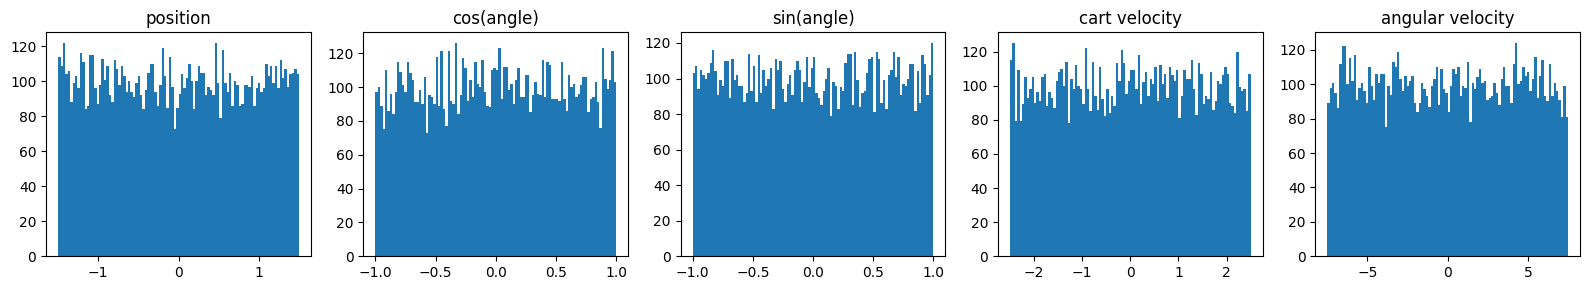

In [35]:
import matplotlib.pyplot as plt

map_variables = {
    0: "position",
    1: "cos(angle)",
    2: "sin(angle)",
    3: "cart velocity",
    4: "angular velocity"
}
fig, axes = plt.subplots(1, obs_uniform.shape[1], figsize=(16, 3))
for i in range(obs_uniform.shape[1]):
    ax = axes[i]
    ax.hist(obs_uniform[:, i], bins=100)
    ax.set_title(f"{map_variables[i]}")
plt.tight_layout()
plt.show()

## UMAP plot

In [ ]:
import umap
import matplotlib.pyplot as plt

# --- UMAP plot for four types of state trajectories: in-policy, off-policy, passive, uniform ---

# Prepare data from the sources
# Note: assumes `obs_episodes_stacked`, `obs_episodes_offpolicy`, `episodes_passive`, `obs_uniform` are defined as above


def flatten_episodes(episodes):
    """Flattens a list of np.arrays or lists into a single 2D array."""
    return np.concatenate([ep for ep in episodes if ep is not None], axis=0)


X_in_policy = obs_inpolicy  # In-policy states
X_off_policy = np.concatenate(obs_episodes_offpolicy,
                              axis=0)  # Off-policy states
X_passive = np.concatenate([ep for ep in episodes_passive if ep is not None],
                           axis=0)  # Passive (autonomous) states


# Optionally sample to limit size for viz (e.g. max 5000 points per group)
def downsample(X, max_n=5000, rng=0):
    np.random.seed(rng)
    if len(X) > max_n:
        idx = np.random.choice(len(X), max_n, replace=False)
        return X[idx]
    else:
        return X


X_in_policy_ds = downsample(X_in_policy)
X_off_policy_ds = downsample(X_off_policy)
X_passive_ds = downsample(X_passive)
X_uniform_ds = downsample(obs_uniform)

# Stack all and label
X_umap = np.concatenate(
    [X_in_policy_ds, X_off_policy_ds, X_passive_ds, X_uniform_ds], axis=0)
labels = (["In-policy"] * len(X_in_policy_ds) +
          ["Off-policy"] * len(X_off_policy_ds) +
          ["Passive"] * len(X_passive_ds) + ["Uniform"] * len(X_uniform_ds),)

# Colors for each group (for plotting later), add 'gray' for uniform
label_to_color = {
    "In-policy": "tab:blue",
    "Off-policy": "tab:orange",
    "Passive": "tab:green",
    "Uniform": "gray"
}

# Run UMAP
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.2, random_state=42)
X_umap_proj = umap_model.fit_transform(X_umap)


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


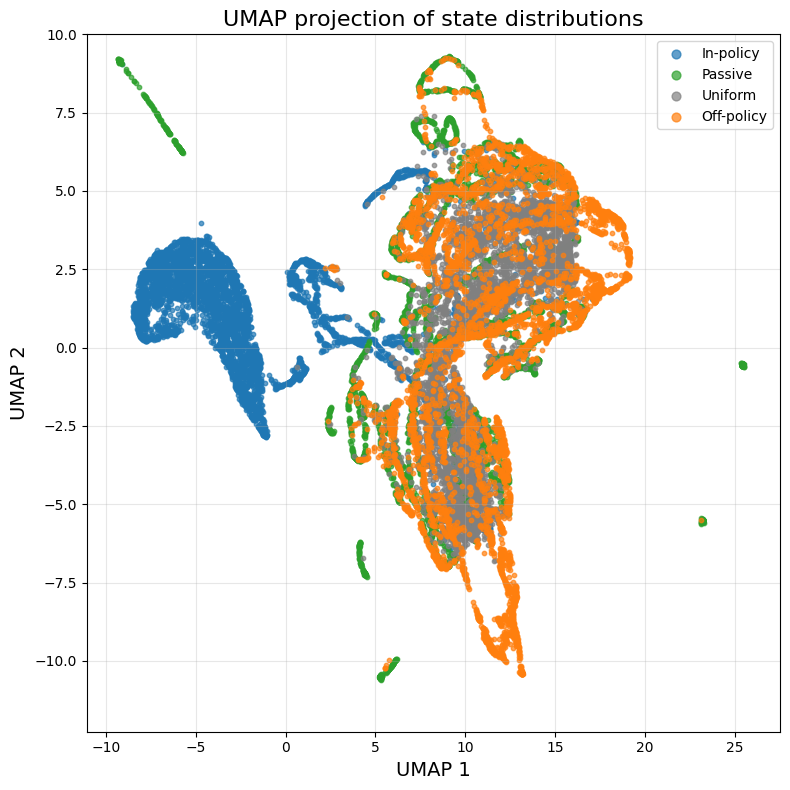

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for label in set(labels):
    idxs = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(X_umap_proj[idxs, 0],
                X_umap_proj[idxs, 1],
                label=label,
                s=10,
                alpha=0.7,
                color=label_to_color[label])
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)
plt.title("UMAP projection of state distributions", fontsize=16)
plt.legend(markerscale=2)
plt.grid(True, alpha=0.3)
plt.ylim(None, 10)
plt.tight_layout()
plt.show()